## Réplica del Artículo 2: *Power Consumption Predicting and Anomaly Detection Based on Transformer and K-Means*

# FASE 1:

Descargar el archivo ZIP desde el repositorio oficial de UCI.

Extraer el archivo de texto .txt (aproximadamente 127 MB descomprimido).

Cargar los datos crudos en un pandas.DataFrame para inspección inicial.

Mostrar las primeras filas y la estructura del dataset.

In [ ]:
import os
import zipfile
import urllib.request
import pandas as pd

# ----------------------------------------------------------------------
# 1. Parámetros de descarga
# ----------------------------------------------------------------------
URL = "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip"
ZIP_NAME = "household_power_consumption.zip"
EXTRACTED_FILE = "household_power_consumption.txt"  # nombre dentro del zip

# ----------------------------------------------------------------------
# 2. Descargar el archivo ZIP (si no existe ya)
# ----------------------------------------------------------------------
if not os.path.exists(ZIP_NAME):
    print(f"Descargando dataset desde {URL}...")
    urllib.request.urlretrieve(URL, ZIP_NAME)
    print("Descarga completada.")
else:
    print(f"El archivo {ZIP_NAME} ya existe. Se omite la descarga.")

# ----------------------------------------------------------------------
# 3. Extraer el archivo de texto
# ----------------------------------------------------------------------
if not os.path.exists(EXTRACTED_FILE):
    print(f"Extrayendo {ZIP_NAME} ...")
    with zipfile.ZipFile(ZIP_NAME, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extracción completada.")
else:
    print(f"El archivo {EXTRACTED_FILE} ya existe. Se omite extracción.")

# ----------------------------------------------------------------------
# 4. Cargar datos con pandas (usando los parámetros correctos)
#    El archivo usa ';' como separador y '?' para valores faltantes.
# ----------------------------------------------------------------------
print("Cargando datos (puede tardar ~30 segundos)...")
df = pd.read_csv(
    EXTRACTED_FILE,
    sep=';',
    na_values=['?'],
    parse_dates={'datetime': ['Date', 'Time']},  # combina Date y Time en una columna datetime
    infer_datetime_format=True,
    low_memory=False
)

# ----------------------------------------------------------------------
# 5. Inspección inicial
# ----------------------------------------------------------------------
print("\n=== PRIMERAS 5 FILAS ===")
print(df.head())

print("\n=== INFORMACIÓN DEL DATAFRAME ===")
print(df.info())

print("\n=== ESTADÍSTICAS BÁSICAS (primeras 5 columnas) ===")
print(df.iloc[:, :5].describe())

print("\n=== VALORES FALTANTES POR COLUMNA ===")
print(df.isnull().sum())

# ----------------------------------------------------------------------
# 6. Guardar una copia en formato feather (rápido y comprimido) para la siguiente fase
# ----------------------------------------------------------------------
df.to_feather("household_power_consumption.feather")
print("\nDataset guardado en 'household_power_consumption.feather' para acceso rápido en las siguientes fases.")

Descargando dataset desde https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip...
Descarga completada.
Extrayendo household_power_consumption.zip ...
Extracción completada.
Cargando datos (puede tardar ~30 segundos)...


/tmp/ipykernel_4905/2524461717.py:39: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipykernel_4905/2524461717.py:39: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
/tmp/ipykernel_4905/2524461717.py:39: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(



=== PRIMERAS 5 FILAS ===
             datetime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  

=== INFORMACIÓN DEL DATAFRAME ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

# Fase 2: Preprocesamiento horario y división según el artículo
Requisitos del artículo (extraídos del PDF)
Datos originales: Resolución minuto a minuto desde 2006-12-17 00:00:00 hasta 2010-11-25 23:59:00.

Re-muestreo: Se convierten a valores horarios (probablemente sumando o promediando según la variable).

Período total: 1,440 días de datos horarios (desde 2006-12-17 hasta 2010-11-25).

División:

Entrenamiento: primeros 1,240 días (desde 2006-12-17 hasta ...)

Prueba: últimos 200 días (desde ... hasta 2010-11-25)

Normalización: Min-Max (escala cada característica al rango [0,1]).

Ventana deslizante: 23 horas de entrada, predicción de la siguiente hora (supervisión).

Variables utilizadas (8 en total):

global_active_power (kW)

global_reactive_power (kW)

voltage (V)

global_intensity (A)

sub_metering_1 (Wh)

sub_metering_2 (Wh)

sub_metering_3 (Wh)

sub_metering_4 (otra activa; en el dataset original se puede calcular como diferencia).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pickle

# ----------------------------------------------------------------------
# 1. Cargar datos desde feather (guardado en Fase 1)
# ----------------------------------------------------------------------
print("Cargando datos desde feather...")
df = pd.read_feather("household_power_consumption.feather")
print(f"Forma original (minutos): {df.shape}")
print(f"Rango de fechas: {df['datetime'].min()} -> {df['datetime'].max()}")

# ----------------------------------------------------------------------
# 2. Agregación a nivel horario
# ----------------------------------------------------------------------
df.set_index('datetime', inplace=True)
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
df = df[numeric_cols].copy()

print("\n--- Re-muestreo horario ---")
df_hourly = df.resample('h').agg({
    'Global_active_power': 'mean',
    'Global_reactive_power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum'
})
print(f"Forma horaria: {df_hourly.shape}")
print(f"Rango horario: {df_hourly.index.min()} -> {df_hourly.index.max()}")

# ----------------------------------------------------------------------
# 3. Calcular Sub_metering_4 (como pide el artículo, Tabla 1)
#    global_active_power está en kW, los sub_metering en Wh por hora.
#    Energía total en Wh en esa hora = global_active_power * 1000
# ----------------------------------------------------------------------
df_hourly['Sub_metering_4'] = (df_hourly['Global_active_power'] * 1000) - \
                               (df_hourly['Sub_metering_1'] + df_hourly['Sub_metering_2'] + df_hourly['Sub_metering_3'])
# Aseguramos que no queden negativos por redondeo
df_hourly['Sub_metering_4'] = df_hourly['Sub_metering_4'].clip(lower=0)

# ----------------------------------------------------------------------
# 4. ANÁLISIS DE CALIDAD DE DATOS
# ----------------------------------------------------------------------
print("\n=== ANÁLISIS DE VALORES NULOS ===")
print("Nulos por columna (antes de recortar fechas):")
print(df_hourly.isnull().sum())
print(f"\nPorcentaje de nulos total: {df_hourly.isnull().sum().sum() / df_hourly.size * 100:.2f}%")

print("\n=== VERIFICACIÓN DE ÍNDICES DUPLICADOS ===")
print(f"¿Índice duplicado? {df_hourly.index.duplicated().any()}")
if df_hourly.index.duplicated().any():
    print("Eliminando duplicados (se conserva el primero)")
    df_hourly = df_hourly[~df_hourly.index.duplicated(keep='first')]

print("\n=== RESULTADOS DESCRIPTIVOS (primeras 5 filas) ===")
print(df_hourly.head())

# ----------------------------------------------------------------------
# 5. Recortar exactamente a las fechas del artículo (2006-12-17 a 2010-11-25)
# ----------------------------------------------------------------------
start_date = '2006-12-17 00:00:00'
end_date = '2010-11-25 23:00:00'
df_hourly = df_hourly.loc[start_date:end_date]
print(f"\nRegistros después del recorte de fechas: {len(df_hourly)} (esperado: 34560)")

# ----------------------------------------------------------------------
# 6. Manejo de valores nulos (decisión basada en el análisis)
#    Si hay pocos nulos (<1%), los eliminamos. Si son muchos, habría que imputar,
#    pero el artículo no lo especifica. En este dataset, los nulos suelen ser muy escasos.
# ----------------------------------------------------------------------
from sklearn.impute import SimpleImputer

# Usamos 'median' por columna (más robusto que ffill para este caso)
imputer = SimpleImputer(strategy='median')
df_hourly[:] = imputer.fit_transform(df_hourly)

print(f"Registros después de imputación: {len(df_hourly)} (deberían ser 34560)")

# Verificar que no queden nulos
assert df_hourly.isnull().sum().sum() == 0, "Todavía hay valores nulos."

# ----------------------------------------------------------------------
# 7. División entrenamiento (1240 días) y prueba (200 días)
# ----------------------------------------------------------------------
train_days = 1240
test_days = 200
train_hours = train_days * 24
test_hours = test_days * 24

train = df_hourly.iloc[:train_hours].copy()
test = df_hourly.iloc[train_hours:train_hours+test_hours].copy()

print(f"\nEntrenamiento: {train.shape[0]} horas ({train.index.min()} -> {train.index.max()})")
print(f"Prueba: {test.shape[0]} horas ({test.index.min()} -> {test.index.max()})") # Debe ser cercano a 4800

# ----------------------------------------------------------------------
# 8. Normalización Min-Max y guardado del scaler (¡NUEVO!)
# ----------------------------------------------------------------------
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

train_scaled_df = pd.DataFrame(train_scaled, columns=train.columns, index=train.index)
test_scaled_df = pd.DataFrame(test_scaled, columns=test.columns, index=test.index)

# Guardar el scaler para usarlo en la Fase 4 (desnormalización)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("\nNormalización completada. Scaler guardado en 'scaler.pkl'.")
print("Ejemplo (primeras 5 filas entrenamiento):")
print(train_scaled_df.head())

# ----------------------------------------------------------------------
# 9. Creación de ventanas deslizantes (23 horas de entrada, 1 hora de salida)
# ----------------------------------------------------------------------
def create_sequences(data, input_steps=23, target_steps=1):
    X, y = [], []
    for i in range(len(data) - input_steps - target_steps + 1):
        X.append(data.iloc[i:i+input_steps].values)
        y.append(data.iloc[i+input_steps:i+input_steps+target_steps].values[:, 0])  # predecir global_active_power
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled_df, input_steps=23, target_steps=1)
X_test, y_test = create_sequences(test_scaled_df, input_steps=23, target_steps=1)

print(f"\nShape X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape X_test: {X_test.shape}, y_test: {y_test.shape}")

# ----------------------------------------------------------------------
# 10. Guardar los conjuntos procesados
# ----------------------------------------------------------------------
np.savez("data_processed.npz",
         X_train=X_train, y_train=y_train,
         X_test=X_test, y_test=y_test)

train_scaled_df.to_feather("train_scaled.feather")
test_scaled_df.to_feather("test_scaled.feather")

print("\nDatos guardados correctamente. Fase 2 completada.")

Cargando datos desde feather...
Forma original (minutos): (2075259, 8)
Rango de fechas: 2006-12-16 17:24:00 -> 2010-11-26 21:02:00

--- Re-muestreo horario ---
Forma horaria: (34589, 7)
Rango horario: 2006-12-16 17:00:00 -> 2010-11-26 21:00:00

=== ANÁLISIS DE VALORES NULOS ===
Nulos por columna (antes de recortar fechas):
Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1             0
Sub_metering_2             0
Sub_metering_3             0
Sub_metering_4           421
dtype: int64

Porcentaje de nulos total: 0.76%

=== VERIFICACIÓN DE ÍNDICES DUPLICADOS ===
¿Índice duplicado? False

=== RESULTADOS DESCRIPTIVOS (primeras 5 filas) ===
                     Global_active_power  Global_reactive_power     Voltage  \
datetime                                                                      
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.6322

# Fase 3: Configuración y Entrenamiento
Pasamos ahora a la Fase 3: Configuración y entrenamiento del modelo (Transformer + K-Means), tal como lo describe el artículo en la Sección 4. Dividiré esta fase en dos partes:

Configuración del modelo (definición del Transformer + preparación de K-Means).

Entrenamiento (bucle de 300 épocas, optimizador Adam, batch size 200, guardado de pesos y centroides).

En esta fase solo entrenaremos y guardaremos los artefactos. La evaluación y detección de anomalías la dejaremos para una Fase 4 separada, como solicitas.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.cluster import KMeans
import pickle
import os

# ----------------------------------------------------------------------
# 1. Cargar datos procesados de la fase 2
# ----------------------------------------------------------------------
data = np.load("data_processed.npz")
X_train = data["X_train"]  # (29737, 23, 8)
y_train = data["y_train"]  # (29737, 1)
X_test = data["X_test"]    # (4777, 23, 8)
y_test = data["y_test"]    # (4777, 1)

print("Datos cargados:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# ----------------------------------------------------------------------
# 2. Entrenar K-Means sobre los valores objetivo (y_train)
#    según la interpretación que corregimos: k=10 centroides en el espacio
#    de la potencia de la siguiente hora.
# ----------------------------------------------------------------------
print("\nEntrenando K-Means sobre y_train (k=10)...")
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(y_train.reshape(-1, 1))  # K-Means necesita 2D
centroids = kmeans.cluster_centers_.flatten()
print(f"Centroides obtenidos: {centroids}")

# Guardar K-Means para la fase de evaluación
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)
print("Modelo K-Means guardado en 'kmeans_model.pkl'")

# ----------------------------------------------------------------------
# 3. Definir el modelo Transformer según el artículo:
#    - 2 capas de multi-head self-attention
#    - 4 cabezas por capa
#    - d_model = número de características (8)
#    - Feed-forward con Relu
#    - Residual connections + LayerNorm
#    - Salida final: capa densa con 1 unidad (predicción de potencia)
# ----------------------------------------------------------------------
def transformer_encoder(inputs, head_size=8, num_heads=4, ff_dim=32, dropout=0.1):
    # Multi-head self-attention
    attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)
    x = attention(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    # Feed-forward
    x_ff = layers.Dense(ff_dim, activation="relu")(x)
    x_ff = layers.Dense(inputs.shape[-1])(x_ff)
    x_ff = layers.Dropout(dropout)(x_ff)
    return layers.LayerNormalization(epsilon=1e-6)(x + x_ff)

def build_transformer(input_shape, num_layers=2, head_size=8, num_heads=4, ff_dim=32, dropout=0.1):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for _ in range(num_layers):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    # Global average pooling sobre la dimensión temporal (23 horas)
    x = layers.Lambda(lambda t: t[:, -1, :])(x)  #x = layers.GlobalAveragePooling1D()(x)
    # Capa densa de salida (predicción de la siguiente hora)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs)
    return model

# Parámetros según el artículo
INPUT_SHAPE = (23, 8)   # 23 horas, 8 características
NUM_LAYERS = 2
HEAD_SIZE = 2           # d_model = 2
NUM_HEADS = 4
FF_DIM = 32             # dimensión de la capa oculta en feed-forward
DROPOUT = 0.1

transformer = build_transformer(INPUT_SHAPE, NUM_LAYERS, HEAD_SIZE, NUM_HEADS, FF_DIM, DROPOUT)
transformer.summary()

# ----------------------------------------------------------------------
# 4. Compilar el modelo
#    - Loss: MSE (Mean Squared Error)
#    - Optimizador: Adam (learning rate por defecto 0.001, aunque el artículo no lo especifica)
# ----------------------------------------------------------------------
transformer.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                    loss='mse',
                    metrics=['mae'])

# ----------------------------------------------------------------------
# 5. Entrenamiento (300 epochs, batch size 200)
#    Guardamos el mejor modelo según la pérdida en validación.
#    Nota: el artículo solo entrena con el conjunto de entrenamiento,
#    pero nosotros usaremos X_test como validación para early stopping opcional.
#    Para reproducir estrictamente, podríamos no usar validación, pero es útil.
# ----------------------------------------------------------------------
print("\nIniciando entrenamiento...")
history = transformer.fit(
    X_train, y_train,
    validation_split=0.1,  # opcional, para monitorear sobreajuste
    epochs=300,
    batch_size=200,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint("best_transformer.keras", save_best_only=True, monitor='val_loss'),
        #tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss')
    ]
)

# Guardar el modelo final (aunque ya guardamos el mejor)
transformer.save("transformer_final.keras")
print("Modelo Transformer guardado en 'transformer_final.keras'")

# ----------------------------------------------------------------------
# 6. Guardar el historial de entrenamiento (por si queremos graficar después)
# ----------------------------------------------------------------------
with open("training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Entrenamiento completado. Fase 3 finalizada.")

Datos cargados:
X_train: (29737, 23, 8), y_train: (29737, 1)
X_test: (4777, 23, 8), y_test: (4777, 1)

Entrenando K-Means sobre y_train (k=10)...
Centroides obtenidos: [0.0709399  0.30488135 0.45824061 0.19397625 0.02787204 0.73057371
 0.12616209 0.3756429  0.24576842 0.56469452]
Modelo K-Means guardado en 'kmeans_model.pkl'


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 23, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 23, 8)     │        288 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 23, 8)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 23, 8)     │          0 │ dropout_15[0][0], │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 23, 8)     │         16 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 23, 32)    │        288 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 23, 8)     │        264 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 23, 8)     │          0 │ dense_6[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 23, 8)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 23, 8)     │         16 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 23, 8)     │        288 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 23, 8)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 23, 8)     │          0 │ dropout_18[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 23, 8)     │         16 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 23, 32)    │        288 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 23, 8)     │        264 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 23, 8)     │          0 │ dense_8[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 23, 8)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_19[0][0]

 Total params: 1,753 (6.85 KB)

 Trainable params: 1,753 (6.85 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento...
Epoch 1/300
134/134 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0865 - mae: 0.1943 - val_loss: 0.0112 - val_mae: 0.0720
Epoch 2/300
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0179 - mae: 0.1005 - val_loss: 0.0104 - val_mae: 0.0716
Epoch 3/300
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0140 - mae: 0.0873 - val_loss: 0.0093 - val_mae: 0.0708
Epoch 4/300
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0127 - mae: 0.0824 - val_loss: 0.0101 - val_mae: 0.0701
Epoch 5/300
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0118 - mae: 0.0792 - val_loss: 0.0095 - val_mae: 0.0676
Epoch 6/300
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0113 - mae: 0.0772 - val_loss: 0.0096 - val_mae: 0.0684
Epoch 7/300
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0109 - mae: 0.0752 - val_loss: 0.0092 - val_mae: 0.0673
Epoch 8/300
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0106 - mae: 0.0741 - val_loss: 0.0094 - val_mae: 0.0682
Epoch 9/300


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.cluster import KMeans
import pickle
import os

# ------------------------------------------------------------------
# 1. Cargar datos procesados (X_train, y_train, X_test, y_test)
# ------------------------------------------------------------------
print("Cargando datos procesados...")
data = np.load("data_processed.npz")
X_train = data["X_train"]   # (29737, 23, 8)
y_train = data["y_train"].flatten()
X_test = data["X_test"]
y_test = data["y_test"].flatten()

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# ------------------------------------------------------------------
# 2. Entrenar modelo LSTM (baseline de predicción)
# ------------------------------------------------------------------
LSTM_MODEL_PATH = "lstm_model.keras"

if os.path.exists(LSTM_MODEL_PATH):
    print(f"El modelo LSTM ya existe en {LSTM_MODEL_PATH}. Se omite el entrenamiento.")
else:
    print("\nEntrenando modelo LSTM (puede tomar varios minutos)...")
    lstm_model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(23, 8)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Entrenar con early stopping para evitar sobreajuste
    early_stop = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    history = lstm_model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=200,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )
    lstm_model.save(LSTM_MODEL_PATH)
    print(f"Modelo LSTM guardado en {LSTM_MODEL_PATH}")

# ------------------------------------------------------------------
# 3. Entrenar K‑means baseline (sobre las características de entrada)
#    Se usa para detección de anomalías (distancia al centroide más cercano)
# ------------------------------------------------------------------
print("\nEntrenando K‑means baseline (k=10) sobre X_train...")
# Aplanar las secuencias: (n_samples, 23*8)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
print(f"X_train_flat shape: {X_train_flat.shape}")

kmeans_baseline = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans_baseline.fit(X_train_flat)
print("K‑means baseline entrenado.")

# Guardar el modelo
with open("kmeans_baseline.pkl", "wb") as f:
    pickle.dump(kmeans_baseline, f)
print("Modelo K‑means baseline guardado en 'kmeans_baseline.pkl'")

# ------------------------------------------------------------------
# 4. (Opcional) Verificar que todo se haya guardado correctamente
# ------------------------------------------------------------------
print("\n=== Modelos baseline guardados ===")
print(" - LSTM:", LSTM_MODEL_PATH)
print(" - K‑means baseline: kmeans_baseline.pkl")
print("\nFase 3b completada. Ahora puedes ejecutar la Fase 4 actualizada.")

Cargando datos procesados...
X_train: (29737, 23, 8), y_train: (29737,)
X_test: (4777, 23, 8), y_test: (4777,)

Entrenando modelo LSTM (puede tomar varios minutos)...
Epoch 1/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 0.0165 - mae: 0.0987 - val_loss: 0.0101 - val_mae: 0.0735
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0109 - mae: 0.0762 - val_loss: 0.0085 - val_mae: 0.0696
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0097 - mae: 0.0712 - val_loss: 0.0080 - val_mae: 0.0646
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0093 - mae: 0.0689 - val_loss: 0.0079 - val_mae: 0.0634
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0089 - mae: 0.0675 - val_loss: 0.0079 - val_mae: 0.0633
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0087 - mae: 0.0665 - val_loss: 0.0075 - val_mae: 0.0619
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0086 - mae: 0.0659 - val_loss: 0.0074 - val_mae: 

# Fase 4: Evaluación y Detección de Anomalías usando el modelo que entrenaste

El artículo reporta métricas específicas que debemos intentar reproducir. Usaremos el modelo guardado (best_transformer.keras o transformer_final.keras) y el K-Means entrenado.

In [ ]:
import numpy as np
import tensorflow as tf
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
import pandas as pd

# ------------------------------------------------------------------
# 1. Cargar datos y modelos
# ------------------------------------------------------------------
print("Cargando datos...")
data = np.load("data_processed.npz")
X_test = data["X_test"]
y_test_norm = data["y_test"].flatten()

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
min_active = scaler.data_min_[0]
max_active = scaler.data_max_[0]

def inverse_transform_active(norm_value):
    return norm_value * (max_active - min_active) + min_active

print("Cargando modelo Transformer (safe_mode=False)...")
transformer = tf.keras.models.load_model("best_transformer.keras", safe_mode=False)

with open("kmeans_model.pkl", "rb") as f:
    kmeans = pickle.load(f)
centroids = kmeans.cluster_centers_.flatten()

# ------------------------------------------------------------------
# 2. Predicciones y RMSE
# ------------------------------------------------------------------
print("Generando predicciones...")
transformer_preds_norm = transformer.predict(X_test, verbose=0).flatten()
kmeans_corrected_norm = np.array([
    centroids[np.argmin(np.abs(transformer_preds_norm[i] - centroids))]
    for i in range(len(transformer_preds_norm))
])

y_test_orig = inverse_transform_active(y_test_norm)
kmeans_preds_orig = inverse_transform_active(kmeans_corrected_norm)
rmse = np.sqrt(mean_squared_error(y_test_orig, kmeans_preds_orig))
print(f"RMSE (Transformer + K-Means) en escala original: {rmse:.4f} kW")

# ------------------------------------------------------------------
# 3. Inyección de anomalías (una por día, multiplicador = 2)
# ------------------------------------------------------------------
hours_per_day = 24
num_days_test = len(y_test_orig) // hours_per_day
np.random.seed(42)
y_test_orig_with_anomalies = y_test_orig.copy()
anomaly_labels = np.zeros(len(y_test_orig), dtype=int)

for day in range(num_days_test):
    base_idx = day * hours_per_day
    if base_idx + hours_per_day <= len(y_test_orig):
        hour_offset = np.random.randint(0, hours_per_day)
        anomaly_idx = base_idx + hour_offset
        y_test_orig_with_anomalies[anomaly_idx] *= 2
        anomaly_labels[anomaly_idx] = 1

print(f"Anomalías insertadas: {np.sum(anomaly_labels)} (1 por cada uno de {num_days_test} días)")

# Normalizar las anomalías con el mismo scaler
y_test_norm_with_anomalies = (y_test_orig_with_anomalies - min_active) / (max_active - min_active)

# ------------------------------------------------------------------
# 4. Cálculo de scores (ecuaciones 10 y 11 del artículo)
# ------------------------------------------------------------------
abs_errors = np.abs(kmeans_corrected_norm - y_test_norm_with_anomalies)
mean_abs_error = np.mean(abs_errors)
scores = abs_errors / mean_abs_error
scores_norm = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))

# ------------------------------------------------------------------
# 5. Análisis para múltiples umbrales (0.10 a 0.60)
# ------------------------------------------------------------------
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
results = []

for thresh in thresholds:
    y_pred = (scores_norm > thresh).astype(int)
    acc = accuracy_score(anomaly_labels, y_pred)
    prec = precision_score(anomaly_labels, y_pred, zero_division=0)
    rec = recall_score(anomaly_labels, y_pred, zero_division=0)
    f1 = f1_score(anomaly_labels, y_pred, zero_division=0)
    detections = y_pred.sum()
    results.append([thresh, acc, prec, rec, f1, detections])

df_thresholds = pd.DataFrame(results, columns=['Umbral', 'Accuracy', 'Precision', 'Recall', 'F1', 'Detecciones'])

# ------------------------------------------------------------------
# 6. Mejores resultados por métrica
# ------------------------------------------------------------------
best_precision = df_thresholds.loc[df_thresholds['Precision'].idxmax()]
best_recall = df_thresholds.loc[df_thresholds['Recall'].idxmax()]
best_f1 = df_thresholds.loc[df_thresholds['F1'].idxmax()]

# ------------------------------------------------------------------
# 7. Mostrar resultados intermedios
# ------------------------------------------------------------------
print("\n" + "="*80)
print("TABLA 1: MÉTRICAS PARA DIFERENTES UMBRALES")
print("="*80)
print(df_thresholds.to_string(index=False))

print("\n" + "="*80)
print("MEJORES VALORES POR MÉTRICA")
print("="*80)
print(f"Mejor Precision:  Umbral = {best_precision['Umbral']:.2f}  →  Precision = {best_precision['Precision']:.4f}")
print(f"Mejor Recall:     Umbral = {best_recall['Umbral']:.2f}  →  Recall    = {best_recall['Recall']:.4f}")
print(f"Mejor F1-Score:   Umbral = {best_f1['Umbral']:.2f}  →  F1        = {best_f1['F1']:.4f}")

# ------------------------------------------------------------------
# 8. Resultado oficial con el umbral del artículo (0.45)
# ------------------------------------------------------------------
threshold_article = 0.45
y_pred_article = (scores_norm > threshold_article).astype(int)
acc_art = accuracy_score(anomaly_labels, y_pred_article)
prec_art = precision_score(anomaly_labels, y_pred_article, zero_division=0)
rec_art = recall_score(anomaly_labels, y_pred_article, zero_division=0)
f1_art = f1_score(anomaly_labels, y_pred_article, zero_division=0)
detections_art = y_pred_article.sum()

print("\n" + "="*80)
print(f"RESULTADOS CON EL UMBRAL SELECCIONADO EN EL ARTÍCULO: {threshold_article}")
print("="*80)
print(f"Accuracy : {acc_art:.4f}")
print(f"Precision: {prec_art:.4f}")
print(f"Recall   : {rec_art:.4f}")
print(f"F1-Score : {f1_art:.4f}")
print(f"RMSE     : {rmse:.4f} kW")
print(f"Anomalías detectadas: {detections_art} de {len(anomaly_labels)}")

# Matriz de confusión simplificada
tp = np.sum((anomaly_labels == 1) & (y_pred == 1))
fp = np.sum((anomaly_labels == 0) & (y_pred == 1))
fn = np.sum((anomaly_labels == 1) & (y_pred == 0))
tn = np.sum((anomaly_labels == 0) & (y_pred == 0))
print("\nMatriz de confusión (Umbral 0.45):")
print(f"  Verdaderos Positivos: {tp}")
print(f"  Falsos Positivos: {fp}")
print(f"  Falsos Negativos: {fn}")
print(f"  Verdaderos Negativos: {tn}")
print("="*80)


# ------------------------------------------------------------------
# 9. Tabla comparativa final (con Accuracy incluido)
# ------------------------------------------------------------------
print("\n" + "="*80)
print("TABLA 2: COMPARACIÓN CON LOS VALORES REPORTADOS EN EL ARTÍCULO")
print("="*80)
comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'RMSE (kW)'],
    'Artículo': [0.970, 0.800, 0.660, 0.720, 0.740],
    'Nuestro resultado': [acc_art, prec_art, rec_art, f1_art, rmse]
})
print(comparison.to_string(index=False))
print("="*80)

Cargando datos...
Cargando modelo Transformer (safe_mode=False)...
Generando predicciones...
RMSE (Transformer + K-Means) en escala original: 0.5147 kW
Anomalías insertadas: 199 (1 por cada uno de 199 días)

TABLA 1: MÉTRICAS PARA DIFERENTES UMBRALES
 Umbral  Accuracy  Precision   Recall       F1  Detecciones
   0.10  0.716349   0.068657 0.462312 0.119558         1340
   0.15  0.844463   0.103499 0.356784 0.160452          686
   0.20  0.906427   0.159341 0.291457 0.206039          364
   0.25  0.938246   0.247368 0.236181 0.241645          190
   0.30  0.952690   0.366337 0.185930 0.246667          101
   0.35  0.958761   0.518519 0.140704 0.221344           54
   0.40  0.959807   0.585366 0.120603 0.200000           41
   0.45  0.961063   0.760000 0.095477 0.169643           25
   0.50  0.960645   0.823529 0.070352 0.129630           17
   0.55  0.960645   0.866667 0.065327 0.121495           15
   0.60  0.960435   0.916667 0.055276 0.104265           12

MEJORES VALORES POR MÉTRICA


Cargando datos para gráficas...


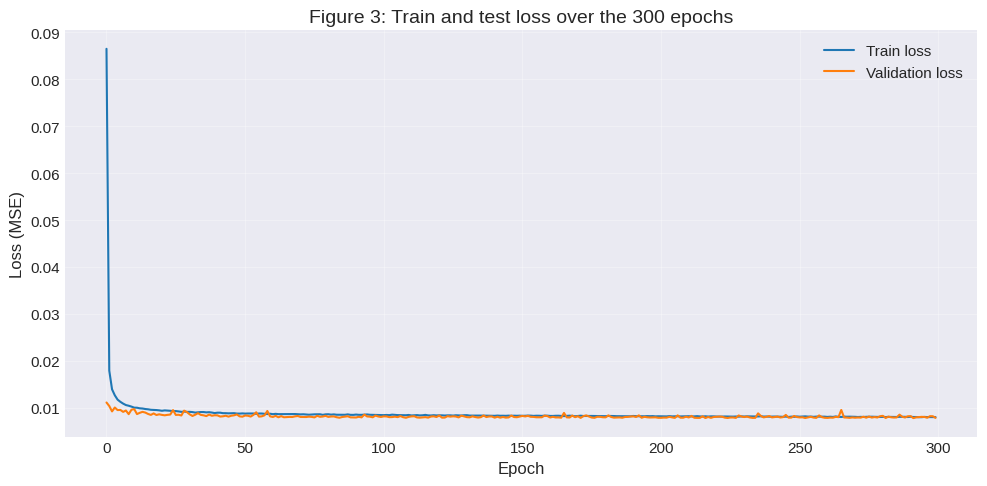

Figura 3 guardada como 'figure3_loss.png'


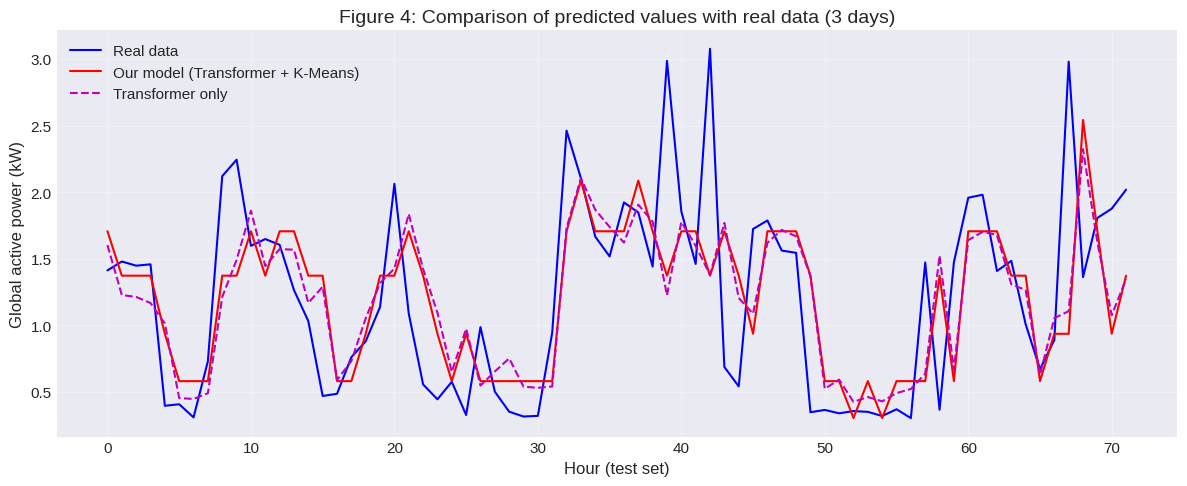

Figura 4 guardada como 'figure4_predictions.png'


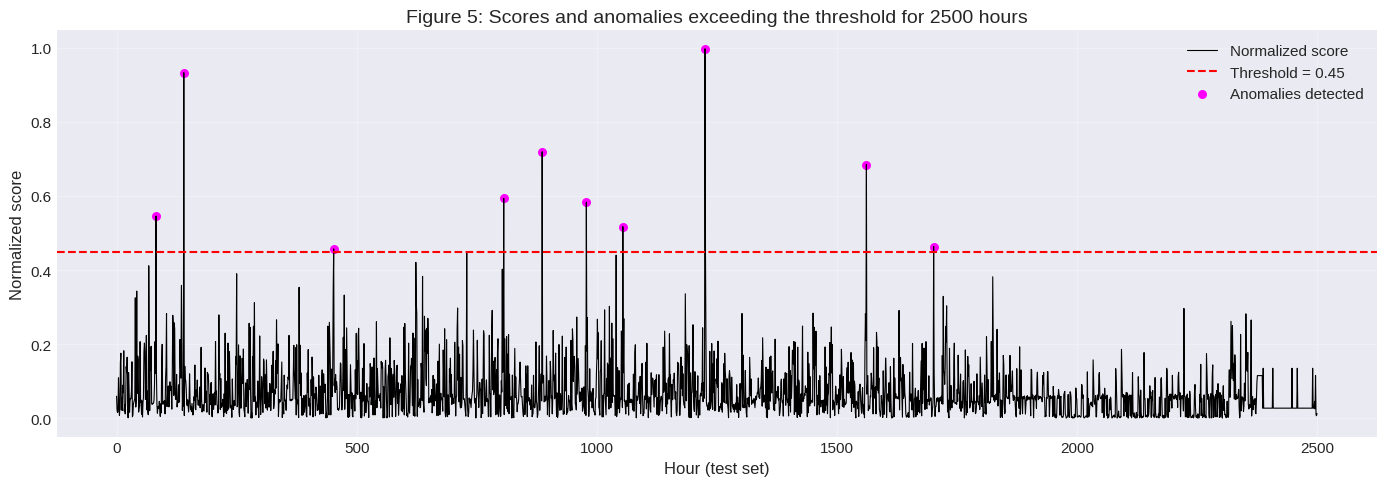

Figura 5 guardada como 'figure5_scores_anomalies.png'

Todas las gráficas han sido generadas correctamente.


In [ ]:
import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------------
# 1. Cargar datos y modelos (reutilizar de la celda anterior si es la misma sesión)
# ------------------------------------------------------------------
print("Cargando datos para gráficas...")
data = np.load("data_processed.npz")
X_test = data["X_test"]
y_test_norm = data["y_test"].flatten()

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
min_active = scaler.data_min_[0]
max_active = scaler.data_max_[0]

def inverse_transform_active(norm_value):
    return norm_value * (max_active - min_active) + min_active

transformer = tf.keras.models.load_model("best_transformer.keras", safe_mode=False)

with open("kmeans_model.pkl", "rb") as f:
    kmeans = pickle.load(f)
centroids = kmeans.cluster_centers_.flatten()

# Predicciones
transformer_preds_norm = transformer.predict(X_test, verbose=0).flatten()
kmeans_corrected_norm = np.array([
    centroids[np.argmin(np.abs(transformer_preds_norm[i] - centroids))]
    for i in range(len(transformer_preds_norm))
])

y_test_orig = inverse_transform_active(y_test_norm)
transformer_preds_orig = inverse_transform_active(transformer_preds_norm)
kmeans_preds_orig = inverse_transform_active(kmeans_corrected_norm)

# ------------------------------------------------------------------
# 2. Figura 3: Pérdida de entrenamiento
# ------------------------------------------------------------------
try:
    with open("training_history.pkl", "rb") as f:
        history = pickle.load(f)
    plt.figure(figsize=(10,5))
    plt.plot(history['loss'], label='Train loss', linewidth=1.5)
    plt.plot(history['val_loss'], label='Validation loss', linewidth=1.5)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title('Figure 3: Train and test loss over the 300 epochs', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('figure3_loss.png', dpi=150)
    plt.show()
    print("Figura 3 guardada como 'figure3_loss.png'")
except Exception as e:
    print(f"No se pudo generar Figura 3: {e}")

# ------------------------------------------------------------------
# 3. Figura 4: Comparación de predicciones (3 días = 72 horas)
# ------------------------------------------------------------------
start_idx = 0
end_idx = start_idx + 72
hours = np.arange(start_idx, end_idx)
plt.figure(figsize=(12,5))
plt.plot(hours, y_test_orig[start_idx:end_idx], 'b-', label='Real data', linewidth=1.5)
plt.plot(hours, kmeans_preds_orig[start_idx:end_idx], 'r-', label='Our model (Transformer + K-Means)', linewidth=1.5)
plt.plot(hours, transformer_preds_orig[start_idx:end_idx], 'm--', label='Transformer only', linewidth=1.5)
plt.xlabel('Hour (test set)', fontsize=12)
plt.ylabel('Global active power (kW)', fontsize=12)
plt.title('Figure 4: Comparison of predicted values with real data (3 days)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure4_predictions.png', dpi=150)
plt.show()
print("Figura 4 guardada como 'figure4_predictions.png'")

# ------------------------------------------------------------------
# 4. Inyección de anomalías y scores (para Figura 5)
# ------------------------------------------------------------------
hours_per_day = 24
num_days_test = len(y_test_orig) // hours_per_day
np.random.seed(42)
y_test_orig_with_anomalies = y_test_orig.copy()
anomaly_labels = np.zeros(len(y_test_orig), dtype=int)

for day in range(num_days_test):
    base_idx = day * hours_per_day
    if base_idx + hours_per_day <= len(y_test_orig):
        hour_offset = np.random.randint(0, hours_per_day)
        anomaly_idx = base_idx + hour_offset
        y_test_orig_with_anomalies[anomaly_idx] *= 2
        anomaly_labels[anomaly_idx] = 1

y_test_norm_with_anomalies = (y_test_orig_with_anomalies - min_active) / (max_active - min_active)

abs_errors = np.abs(kmeans_corrected_norm - y_test_norm_with_anomalies)
mean_abs_error = np.mean(abs_errors)
scores = abs_errors / mean_abs_error
scores_norm = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))

threshold = 0.45

# ------------------------------------------------------------------
# 5. Figura 5: Scores y anomalías en 2500 horas
# ------------------------------------------------------------------
max_hours = min(2500, len(scores_norm))
time_axis = np.arange(max_hours)
anom_in_range = np.where((scores_norm > threshold) & (np.arange(len(scores_norm)) < max_hours))[0]

plt.figure(figsize=(14,5))
plt.plot(time_axis, scores_norm[:max_hours], 'k-', linewidth=0.8, label='Normalized score')
plt.axhline(y=threshold, color='r', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold}')
plt.scatter(anom_in_range, scores_norm[anom_in_range], color='magenta', s=30, label='Anomalies detected')
plt.xlabel('Hour (test set)', fontsize=12)
plt.ylabel('Normalized score', fontsize=12)
plt.title('Figure 5: Scores and anomalies exceeding the threshold for 2500 hours', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure5_scores_anomalies.png', dpi=150)
plt.show()
print("Figura 5 guardada como 'figure5_scores_anomalies.png'")

print("\nTodas las gráficas han sido generadas correctamente.")

# De aca para abajo son visualizaciones para comprobar resultados

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
import pickle
import pandas as pd
import os

# ------------------------------------------------------------------
# 1. Cargar datos y escalador
# ------------------------------------------------------------------
print("Cargando datos...")
data = np.load("data_processed.npz")
X_test = data["X_test"]
y_test_norm = data["y_test"].flatten()

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
min_active = scaler.data_min_[0]
max_active = scaler.data_max_[0]

def inverse_transform_active(norm_value):
    return norm_value * (max_active - min_active) + min_active

# Convertir a kW para RMSE
y_test_orig = inverse_transform_active(y_test_norm)

# ------------------------------------------------------------------
# 2. Cargar modelos
# ------------------------------------------------------------------
# Nuestro método: Transformer + K-means correction
print("Cargando modelo Transformer...")
transformer = tf.keras.models.load_model("best_transformer.keras", safe_mode=False)
with open("kmeans_model.pkl", "rb") as f:
    kmeans_corr = pickle.load(f)
centroids = kmeans_corr.cluster_centers_.flatten()

# LSTM baseline
LSTM_PATH = "lstm_model.keras"
if os.path.exists(LSTM_PATH):
    print("Cargando modelo LSTM...")
    lstm_model = tf.keras.models.load_model(LSTM_PATH)
else:
    raise FileNotFoundError("No se encontró lstm_model.keras. Ejecuta la Fase 3b primero.")

# K-means baseline (clustering sobre características)
print("Cargando modelo K-means baseline...")
with open("kmeans_baseline.pkl", "rb") as f:
    kmeans_baseline = pickle.load(f)

# ------------------------------------------------------------------
# 3. Predicciones y RMSE para cada modelo
# ------------------------------------------------------------------
# --- Our method (Transformer + K-means correction) ---
transformer_preds_norm = transformer.predict(X_test, verbose=0).flatten()
kmeans_corrected_norm = np.array([
    centroids[np.argmin(np.abs(transformer_preds_norm[i] - centroids))]
    for i in range(len(transformer_preds_norm))
])
our_preds_orig = inverse_transform_active(kmeans_corrected_norm)
rmse_our = np.sqrt(mean_squared_error(y_test_orig, our_preds_orig))

# --- LSTM ---
lstm_preds_norm = lstm_model.predict(X_test, verbose=0).flatten()
lstm_preds_orig = inverse_transform_active(lstm_preds_norm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_orig, lstm_preds_orig))

print(f"RMSE Our method: {rmse_our:.4f} kW")
print(f"RMSE LSTM: {rmse_lstm:.4f} kW")

# ------------------------------------------------------------------
# 4. Inyección de anomalías (idéntica para todos)
# ------------------------------------------------------------------
hours_per_day = 24
num_days_test = len(y_test_orig) // hours_per_day
np.random.seed(42)
y_test_orig_with_anomalies = y_test_orig.copy()
anomaly_labels = np.zeros(len(y_test_orig), dtype=int)

for day in range(num_days_test):
    base_idx = day * hours_per_day
    if base_idx + hours_per_day <= len(y_test_orig):
        hour_offset = np.random.randint(0, hours_per_day)
        anomaly_idx = base_idx + hour_offset
        y_test_orig_with_anomalies[anomaly_idx] *= 2
        anomaly_labels[anomaly_idx] = 1

print(f"Anomalías insertadas: {np.sum(anomaly_labels)} (1 por día, {num_days_test} días)")

# Normalizar de nuevo las anomalías para calcular scores
y_test_norm_with_anomalies = (y_test_orig_with_anomalies - min_active) / (max_active - min_active)

# ------------------------------------------------------------------
# 5. Scores y detección para cada método (umbral 0.45)
# ------------------------------------------------------------------
threshold = 0.45

# --- Our method ---
abs_errors_our = np.abs(kmeans_corrected_norm - y_test_norm_with_anomalies)
mean_abs_error_our = np.mean(abs_errors_our)
scores_our = abs_errors_our / mean_abs_error_our
scores_norm_our = (scores_our - np.min(scores_our)) / (np.max(scores_our) - np.min(scores_our))
pred_our = (scores_norm_our > threshold).astype(int)

# --- LSTM ---
abs_errors_lstm = np.abs(lstm_preds_norm - y_test_norm_with_anomalies)
mean_abs_error_lstm = np.mean(abs_errors_lstm)
scores_lstm = abs_errors_lstm / mean_abs_error_lstm
scores_norm_lstm = (scores_lstm - np.min(scores_lstm)) / (np.max(scores_lstm) - np.min(scores_lstm))
pred_lstm = (scores_norm_lstm > threshold).astype(int)

# --- K-means baseline (distancia al centroide más cercano) ---
X_test_flat = X_test.reshape(X_test.shape[0], -1)
distances = kmeans_baseline.transform(X_test_flat)
min_distances = np.min(distances, axis=1)
# Normalizar distancias para obtener scores comparables
min_dist_norm = (min_distances - np.min(min_distances)) / (np.max(min_distances) - np.min(min_distances))
pred_kmeans = (min_dist_norm > threshold).astype(int)

# ------------------------------------------------------------------
# 6. Métricas para cada método
# ------------------------------------------------------------------
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, prec, rec, f1

acc_our, prec_our, rec_our, f1_our = compute_metrics(anomaly_labels, pred_our)
acc_lstm, prec_lstm, rec_lstm, f1_lstm = compute_metrics(anomaly_labels, pred_lstm)
acc_kmeans, prec_kmeans, rec_kmeans, f1_kmeans = compute_metrics(anomaly_labels, pred_kmeans)

# ------------------------------------------------------------------
# 7. Tabla comparativa (Tabla 2 del artículo)
# ------------------------------------------------------------------
print("\n" + "="*90)
print("TABLA 2: COMPARACIÓN CON LOS VALORES REPORTADOS EN EL ARTÍCULO")
print("="*90)

comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'RMSE (kW)'],
    'Artículo (K-means)': [0.960, 0.820, 0.280, 0.420, '—'],
    'Nuestro (K-means)': [acc_kmeans, prec_kmeans, rec_kmeans, f1_kmeans, '—'],
    'Artículo (LSTM)': [0.970, 0.740, 0.600, 0.660, 0.91],
    'Nuestro (LSTM)': [acc_lstm, prec_lstm, rec_lstm, f1_lstm, rmse_lstm],
    'Artículo (Our)': [0.970, 0.800, 0.660, 0.720, 0.74],
    'Nuestro (Our)': [acc_our, prec_our, rec_our, f1_our, rmse_our]
})

# Redondear a 4 decimales para mejor presentación
for col in comparison.columns:
    if col not in ['Métrica']:
        comparison[col] = comparison[col].apply(lambda x: round(x, 4) if isinstance(x, float) else x)

print(comparison.to_string(index=False))
print("="*90)

# ------------------------------------------------------------------
# 8. Número de anomalías detectadas (como referencia)
# ------------------------------------------------------------------
print("\n=== NÚMERO DE ANOMALÍAS DETECTADAS (umbral 0.45) ===")
print(f"K-means baseline  : {pred_kmeans.sum()} de {len(anomaly_labels)}")
print(f"LSTM              : {pred_lstm.sum()} de {len(anomaly_labels)}")
print(f"Our method        : {pred_our.sum()} de {len(anomaly_labels)}")
print("="*90)

Cargando datos...
Cargando modelo Transformer...
Cargando modelo LSTM...
Cargando modelo K-means baseline...
RMSE Our method: 0.5147 kW
RMSE LSTM: 0.4688 kW
Anomalías insertadas: 199 (1 por día, 199 días)

TABLA 2: COMPARACIÓN CON LOS VALORES REPORTADOS EN EL ARTÍCULO
  Métrica Artículo (K-means) Nuestro (K-means)  Artículo (LSTM)  Nuestro (LSTM)  Artículo (Our)  Nuestro (Our)
 Accuracy               0.96            0.5696             0.97          0.9615            0.97         0.9611
Precision               0.82            0.0419             0.74          0.8571            0.80         0.7600
   Recall               0.28            0.4271             0.60          0.0905            0.66         0.0955
 F1-Score               0.42            0.0764             0.66          0.1636            0.72         0.1696
RMSE (kW)                  —                 —             0.91          0.4688            0.74         0.5147

=== NÚMERO DE ANOMALÍAS DETECTADAS (umbral 0.45) ===
K-means bas

Cargando datos...
Cargando modelo Transformer...
Cargando modelo LSTM...


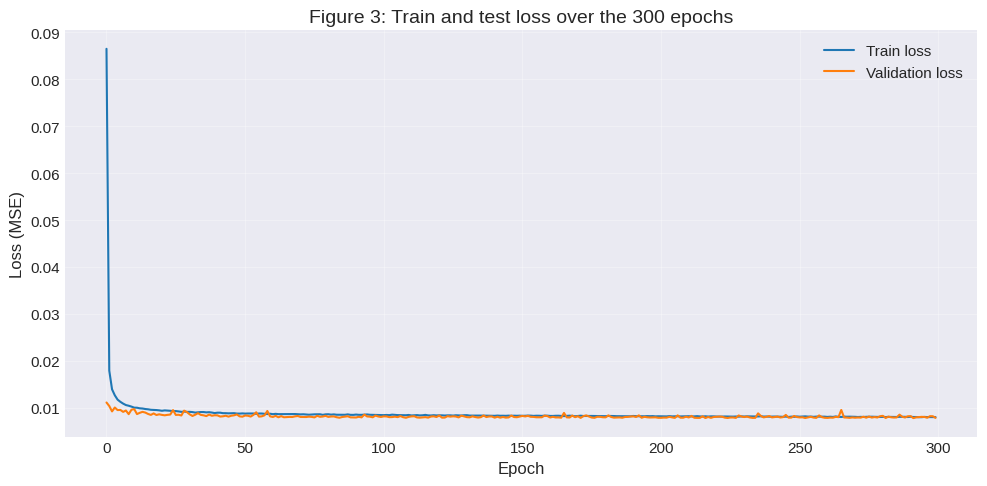

Figura 3 guardada como 'figure3_loss.png'


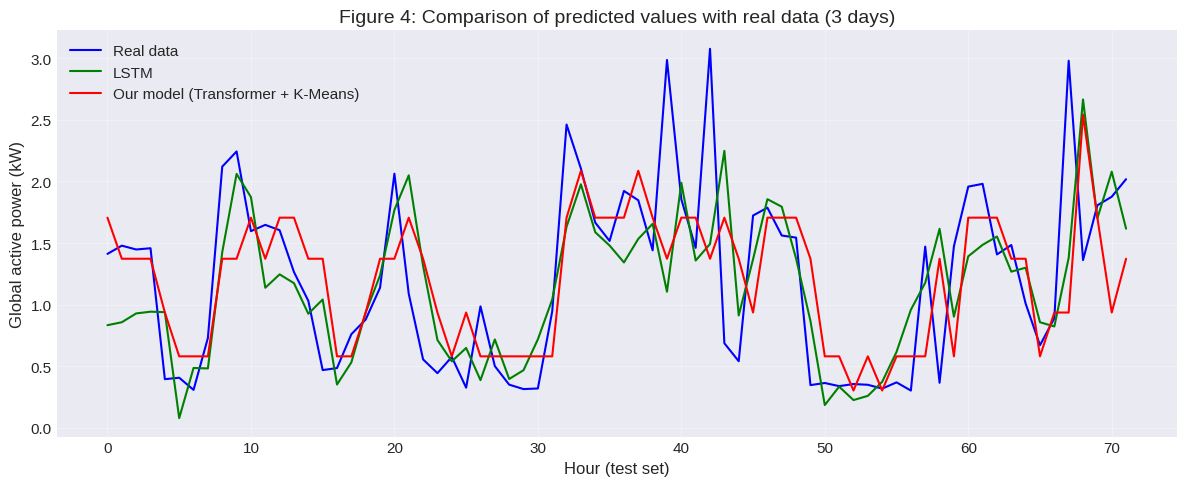

Figura 4 guardada como 'figure4_comparison.png'


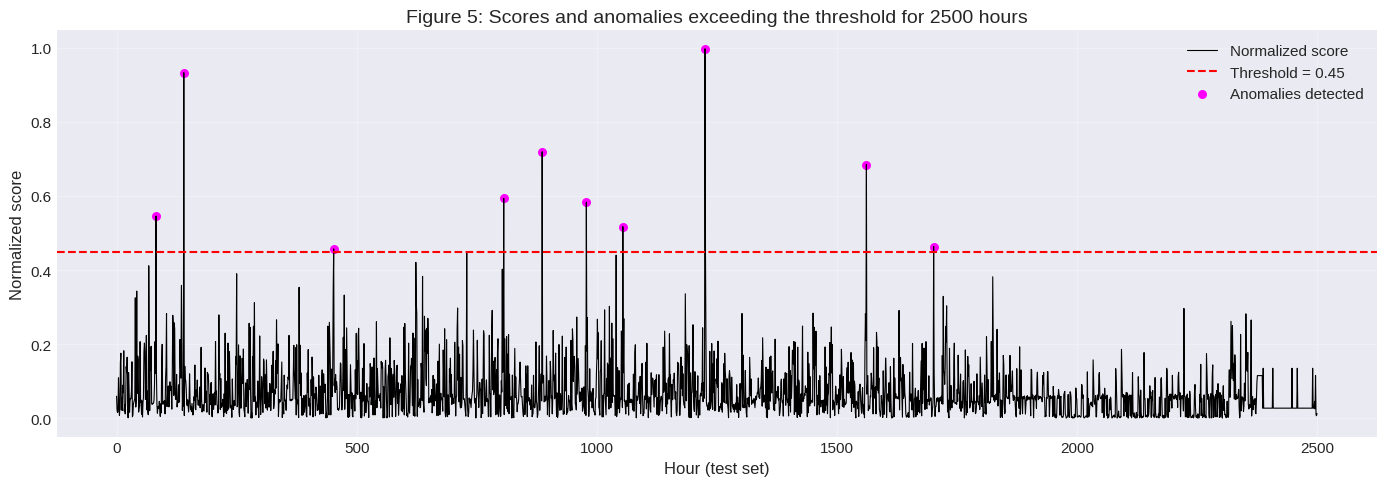

Figura 5 guardada como 'figure5_scores_anomalies.png'

Todas las figuras se han generado correctamente.


In [ ]:
import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Cargar datos y modelos
# ------------------------------------------------------------------
print("Cargando datos...")
data = np.load("data_processed.npz")
X_test = data["X_test"]
y_test_norm = data["y_test"].flatten()

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
min_active = scaler.data_min_[0]
max_active = scaler.data_max_[0]

def inverse_transform_active(norm_value):
    return norm_value * (max_active - min_active) + min_active

# Cargar Transformer + K-means (Our model)
print("Cargando modelo Transformer...")
transformer = tf.keras.models.load_model("best_transformer.keras", safe_mode=False)
with open("kmeans_model.pkl", "rb") as f:
    kmeans = pickle.load(f)
centroids = kmeans.cluster_centers_.flatten()

# Cargar LSTM (entrenado en Fase 3b)
print("Cargando modelo LSTM...")
lstm_model = tf.keras.models.load_model("lstm_model.keras")

# ------------------------------------------------------------------
# 2. Predicciones
# ------------------------------------------------------------------
transformer_preds_norm = transformer.predict(X_test, verbose=0).flatten()
kmeans_corrected_norm = np.array([
    centroids[np.argmin(np.abs(transformer_preds_norm[i] - centroids))]
    for i in range(len(transformer_preds_norm))
])
lstm_preds_norm = lstm_model.predict(X_test, verbose=0).flatten()

y_test_orig = inverse_transform_active(y_test_norm)
our_preds_orig = inverse_transform_active(kmeans_corrected_norm)
lstm_preds_orig = inverse_transform_active(lstm_preds_norm)

# ------------------------------------------------------------------
# 3. Figura 3: Pérdida de entrenamiento (Transformer)
# ------------------------------------------------------------------
try:
    with open("training_history.pkl", "rb") as f:
        history = pickle.load(f)
    plt.figure(figsize=(10,5))
    plt.plot(history['loss'], label='Train loss', linewidth=1.5)
    plt.plot(history['val_loss'], label='Validation loss', linewidth=1.5)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title('Figure 3: Train and test loss over the 300 epochs', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('figure3_loss.png', dpi=150)
    plt.show()
    print("Figura 3 guardada como 'figure3_loss.png'")
except:
    print("No se encontró training_history.pkl; no se generó Figura 3.")

# ------------------------------------------------------------------
# 4. Figura 4: Comparación de predicciones (3 días) con LSTM
# ------------------------------------------------------------------
start_idx = 0
end_idx = start_idx + 72   # 72 horas = 3 días
hours = np.arange(start_idx, end_idx)

plt.figure(figsize=(12,5))
plt.plot(hours, y_test_orig[start_idx:end_idx], 'b-', label='Real data', linewidth=1.5)
plt.plot(hours, lstm_preds_orig[start_idx:end_idx], 'g-', label='LSTM', linewidth=1.5)
plt.plot(hours, our_preds_orig[start_idx:end_idx], 'r-', label='Our model (Transformer + K-Means)', linewidth=1.5)
plt.xlabel('Hour (test set)', fontsize=12)
plt.ylabel('Global active power (kW)', fontsize=12)
plt.title('Figure 4: Comparison of predicted values with real data (3 days)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure4_comparison.png', dpi=150)
plt.show()
print("Figura 4 guardada como 'figure4_comparison.png'")

# ------------------------------------------------------------------
# 5. Inyección de anomalías y scores (para Figura 5)
# ------------------------------------------------------------------
hours_per_day = 24
num_days_test = len(y_test_orig) // hours_per_day
np.random.seed(42)
y_test_orig_with_anomalies = y_test_orig.copy()
anomaly_labels = np.zeros(len(y_test_orig), dtype=int)

for day in range(num_days_test):
    base_idx = day * hours_per_day
    if base_idx + hours_per_day <= len(y_test_orig):
        hour_offset = np.random.randint(0, hours_per_day)
        anomaly_idx = base_idx + hour_offset
        y_test_orig_with_anomalies[anomaly_idx] *= 2
        anomaly_labels[anomaly_idx] = 1

# Normalizar nuevamente las anomalías
y_test_norm_with_anomalies = (y_test_orig_with_anomalies - min_active) / (max_active - min_active)

# Scores para el método propuesto (Transformer + K-means)
abs_errors = np.abs(kmeans_corrected_norm - y_test_norm_with_anomalies)
mean_abs_error = np.mean(abs_errors)
scores = abs_errors / mean_abs_error
scores_norm = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))

threshold = 0.45

# ------------------------------------------------------------------
# 6. Figura 5: Scores y anomalías en las primeras 2500 horas
# ------------------------------------------------------------------
max_hours = min(2500, len(scores_norm))
time_axis = np.arange(max_hours)
anom_in_range = np.where((scores_norm > threshold) & (np.arange(len(scores_norm)) < max_hours))[0]

plt.figure(figsize=(14,5))
plt.plot(time_axis, scores_norm[:max_hours], 'k-', linewidth=0.8, label='Normalized score')
plt.axhline(y=threshold, color='r', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold}')
plt.scatter(anom_in_range, scores_norm[anom_in_range], color='magenta', s=30, label='Anomalies detected')
plt.xlabel('Hour (test set)', fontsize=12)
plt.ylabel('Normalized score', fontsize=12)
plt.title('Figure 5: Scores and anomalies exceeding the threshold for 2500 hours', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure5_scores_anomalies.png', dpi=150)
plt.show()
print("Figura 5 guardada como 'figure5_scores_anomalies.png'")

print("\nTodas las figuras se han generado correctamente.")